In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import shutil
import re

# ==========================================
# 1. パス・設定
# ==========================================
MASTER_CSV = "/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/after_20251225/effective_ExpVar/Feature_Importance_All_Models_Master_20260112.csv"
RAW_DATA_DIR = "/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/20220127_PLS 202201 ALL/20251216_for_making_collect_data_nm_baseall_OHFP_csv/rebuilt_merged_data/"

PARENT_DIR = "/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/after_20251225"
MAIN_OUTPUT_DIR = os.path.join(PARENT_DIR, "CDCA_Method_Comparison_Analysis")

# 二つの手法のフォルダ作成
METHOD1_DIR = os.path.join(MAIN_OUTPUT_DIR, "Method1_Descending_Original")
METHOD2_DIR = os.path.join(MAIN_OUTPUT_DIR, "Method2_Absolute_New")

for d in [METHOD1_DIR, METHOD2_DIR]:
    if not os.path.exists(d): os.makedirs(d)

# ==========================================
# 2. データ読み込み
# ==========================================
print("Loading data...")
df_m_oh = pd.read_csv(os.path.join(RAW_DATA_DIR, "m_all_OH_rebuilt.csv"))
df_m_fp_raw = pd.read_csv(os.path.join(RAW_DATA_DIR, "m_all_FP_rebuilt.csv"))
master_df = pd.read_csv(MASTER_CSV)

id_col = "Var.1"
fp_pattern = re.compile(r'^X\d+\.\d+$')
keep_cols = [id_col] + [c for c in df_m_fp_raw.columns if fp_pattern.match(c)]
df_m_fp = df_m_fp_raw[keep_cols].copy()

targets = ["PCEmax", "Jsc"]
imputations = ["補完", "未補完"]

# ==========================================
# 3. 補助関数
# ==========================================
def get_green_color(val):
    return (1.0 - val * 0.8, 1.0 - val * 0.2, 1.0 - val * 0.8)

def calculate_cdca(oh_list, fp_list):
    rows = [o.replace('SMILESsnamep1M_', '') for o in oh_list]
    mat_up = pd.DataFrame(index=rows, columns=fp_list)
    mat_low = pd.DataFrame(index=rows, columns=fp_list)
    for o_feat, o_lab in zip(oh_list, rows):
        if o_feat not in df_m_oh.columns: continue
        ids_o = df_m_oh[df_m_oh[o_feat] > 0.5][id_col].tolist()
        for f_feat in fp_list:
            if f_feat not in df_m_fp.columns: continue
            ids_f = df_m_fp[df_m_fp[f_feat] > 0][id_col].tolist()
            common = set(ids_o) & set(ids_f)
            mat_up.loc[o_lab, f_feat] = len(common)/len(ids_o) if ids_o else 0
            mat_low.loc[o_lab, f_feat] = len(common)/len(ids_f) if ids_f else 0
    return mat_up.astype(float), mat_low.astype(float)

def draw_diagonal_heatmap(mat_up, mat_low, save_path, title):
    fig, ax = plt.subplots(figsize=(16, 12))
    rows, cols = mat_up.index, mat_up.columns
    ax.set_xlim(0, len(cols)), ax.set_ylim(0, len(rows))
    for i in range(len(rows)):
        for j in range(len(cols)):
            v_up, v_low = mat_up.iloc[i, j], mat_low.iloc[i, j]
            p_up = patches.Polygon([[j, i], [j+1, i], [j+1, i+1]], facecolor=get_green_color(v_up), edgecolor='white', lw=1)
            p_low = patches.Polygon([[j, i], [j+1, i+1], [j, i+1]], facecolor=get_green_color(v_low), edgecolor='white', lw=1)
            ax.add_patch(p_up), ax.add_patch(p_low)
            ax.text(j+0.7, i+0.3, f"{v_up:.2f}", va='center', ha='center', fontsize=7)
            ax.text(j+0.3, i+0.7, f"{v_low:.2f}", va='center', ha='center', fontsize=7)
    ax.set_xticks(np.arange(len(cols)) + 0.5), ax.set_xticklabels(cols, rotation=45, ha='right')
    ax.set_yticks(np.arange(len(rows)) + 0.5), ax.set_yticklabels(rows)
    ax.invert_yaxis()
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.close()

# ==========================================
# 4. メイン比較・解析
# ==========================================
print(f"\n{'='*60}")
print(" Method Comparison: Original (Desc) vs New (Absolute)")
print(f"{'='*60}")

for t in targets:
    for imp in imputations:
        base_df = master_df[(master_df['Target'] == t) & (master_df['Imputation_Type'] == imp)]
        if base_df.empty: continue

        # --- 手法1: 降順 (Original) ---
        oh_m1 = base_df[base_df['Feature'].str.startswith('SMILESsnamep1M')].sort_values('Normalized_Importance', ascending=False).head(15)['Feature'].tolist()
        fp_m1 = base_df[base_df['Feature'].apply(lambda x: bool(fp_pattern.match(str(x))))].sort_values('Normalized_Importance', ascending=False).head(15)['Feature'].tolist()

        # --- 手法2: 絶対値 (Absolute) ---
        oh_m2 = base_df[base_df['Feature'].str.startswith('SMILESsnamep1M')].assign(abs_val=base_df['Normalized_Importance'].abs()).sort_values('abs_val', ascending=False).head(15)['Feature'].tolist()
        fp_m2 = base_df[base_df['Feature'].apply(lambda x: bool(fp_pattern.match(str(x))))].assign(abs_val=base_df['Normalized_Importance'].abs()).sort_values('abs_val', ascending=False).head(15)['Feature'].tolist()

        # --- 比較と表示 ---
        diff_oh = set(oh_m2) - set(oh_m1)
        diff_fp = set(fp_m2) - set(fp_m1)

        if diff_oh or diff_fp:
            print(f"\n[DIFFERENCE DETECTED] Algorithm: {t} ({imp})")
            if diff_oh: print(f"  New Materials in Top15 (Negative Impact): {list(diff_oh)}")
            if diff_fp: print(f"  New Structures in Top15 (Negative Impact): {list(diff_fp)}")
        else:
            print(f"\n[SAME RESULTS] Algorithm: {t} ({imp})")

        # --- CDCA実行と保存 ---
        # Method 1
        m1_up, m1_low = calculate_cdca(oh_m1, fp_m1)
        draw_diagonal_heatmap(m1_up, m1_low, os.path.join(METHOD1_DIR, f"{t}_{imp}_M1_Heatmap.png"), f"M1 (Desc): {t} {imp}")
        m1_up.to_csv(os.path.join(METHOD1_DIR, f"{t}_{imp}_M1_OHtoFP.csv"), encoding='utf-8-sig')

        # Method 2
        m2_up, m2_low = calculate_cdca(oh_m2, fp_m2)
        draw_diagonal_heatmap(m2_up, m2_low, os.path.join(METHOD2_DIR, f"{t}_{imp}_M2_Heatmap.png"), f"M2 (Abs): {t} {imp}")
        m2_up.to_csv(os.path.join(METHOD2_DIR, f"{t}_{imp}_M2_OHtoFP.csv"), encoding='utf-8-sig')

# ZIP作成
shutil.make_archive(MAIN_OUTPUT_DIR, 'zip', root_dir=MAIN_OUTPUT_DIR)
print(f"\n{'='*60}\n Analysis Completed. Results saved in: {MAIN_OUTPUT_DIR}\n{'='*60}")

Loading data...

 Method Comparison: Original (Desc) vs New (Absolute)

[DIFFERENCE DETECTED] Algorithm: PCEmax (補完)
  New Materials in Top15 (Negative Impact): [nan]


/tmp/ipykernel_72941/3442398988.py:65: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_xlim(0, len(cols)), ax.set_ylim(0, len(rows))
/tmp/ipykernel_72941/3442398988.py:78: UserWarning: Glyph 35036 (\N{CJK UNIFIED IDEOGRAPH-88DC}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_72941/3442398988.py:78: UserWarning: Glyph 23436 (\N{CJK UNIFIED IDEOGRAPH-5B8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_72941/3442398988.py:79: UserWarning: Glyph 35036 (\N{CJK UNIFIED IDEOGRAPH-88DC}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300)
/tmp/ipykernel_72941/3442398988.py:79: UserWarning: Glyph 23436 (\N{CJK UNIFIED IDEOGRAPH-5B8C}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300)


AttributeError: 'float' object has no attribute 'replace'

In [2]:
import pandas as pd
import re

# --- パス設定 (お手元の環境に合わせてください) ---
MASTER_CSV = "/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/after_20251225/effective_ExpVar/Feature_Importance_All_Models_Master_20260112.csv"
fp_pattern = re.compile(r'^X\d+\.\d+$')

print("=== デバッグ開始: 変数リストの健全性チェック ===\n")

master_df = pd.read_csv(MASTER_CSV)

# ターゲットと補完タイプごとにチェック
targets = ["PCEmax", "Jsc"]
imputations = ["補完", "未補完"]

for t in targets:
    for imp in imputations:
        print(f"--- Checking: {t} ({imp}) ---")
        base_df = master_df[(master_df['Target'] == t) & (master_df['Imputation_Type'] == imp)]
        
        if base_df.empty:
            print(f"  [警告] データが見つかりません: {t} {imp}")
            continue

        # 1. 材料名(OH)のリストをチェック
        oh_list = base_df[base_df['Feature'].str.startswith('SMILESsnamep1M', na=False)].sort_values('Normalized_Importance', ascending=False).head(15)['Feature'].tolist()
        
        # 2. 構造記述子(FP)のリストをチェック
        fp_list = base_df[base_df['Feature'].apply(lambda x: bool(fp_pattern.match(str(x))))].sort_values('Normalized_Importance', ascending=False).head(15)['Feature'].tolist()

        # --- OHリストの型チェック ---
        for i, val in enumerate(oh_list):
            if not isinstance(val, str):
                print(f"  [!!エラー原因!!] OHリストの {i}番目に不正なデータがあります: 値='{val}', 型={type(val)}")
            elif pd.isna(val):
                print(f"  [!!エラー原因!!] OHリストの {i}番目が NaN です。")

        # --- FPリストの型チェック ---
        for i, val in enumerate(fp_list):
            if not isinstance(val, str):
                print(f"  [!!エラー原因!!] FPリストの {i}番目に不正なデータがあります: 値='{val}', 型={type(val)}")

        print(f"  確認完了: OH数={len(oh_list)}, FP数={len(fp_list)}\n")

print("=== デバッグ終了 ===")

=== デバッグ開始: 変数リストの健全性チェック ===

--- Checking: PCEmax (補完) ---
  確認完了: OH数=0, FP数=15

--- Checking: PCEmax (未補完) ---
  確認完了: OH数=15, FP数=0

--- Checking: Jsc (補完) ---
  確認完了: OH数=0, FP数=15

--- Checking: Jsc (未補完) ---
  確認完了: OH数=15, FP数=0

=== デバッグ終了 ===


In [3]:
import os
import pandas as pd
import numpy as np

# =============================================================================
# 1. 設定：パスと対象の定義
# =============================================================================
RAW_DATA_PATH = "/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/20220127_PLS 202201 ALL/20251216_for_making_collect_data_nm_baseall_OHFP_csv/rebuilt_merged_data/"
FI_MASTER_FILE = "Feature_Importance_All_Models_Master_20260112.csv"

# 出力先の設定
OUTPUT_PARENT = "Impact_Analysis_Comparison"
DIR_METHOD1 = os.path.join(OUTPUT_PARENT, "Method1_Original_Descending")
DIR_METHOD2 = os.path.join(OUTPUT_PARENT, "Method2_New_Absolute")

for d in [DIR_METHOD1, DIR_METHOD2]:
    if not os.path.exists(d):
        os.makedirs(d)

target_configs = [
    {"Target": "PCEmax", "Type": "補完",   "File": "m_all_FP_rebuilt.csv"},
    {"Target": "PCEmax", "Type": "未補完", "File": "n_base_OH_rebuilt.csv"},
    {"Target": "Jsc",    "Type": "補完",   "File": "m_all_FP_rebuilt.csv"},
    {"Target": "Jsc",    "Type": "未補完", "File": "n_base_OH_rebuilt.csv"},
    {"Target": "Voc",    "Type": "補完",   "File": "m_base_FP_rebuilt.csv"},
    {"Target": "Voc",    "Type": "未補完", "File": "n_base_FP_rebuilt.csv"},
    {"Target": "FF",     "Type": "補完",   "File": "m_all_OH_rebuilt.csv"},
    {"Target": "FF",     "Type": "未補完", "File": "n_base_OH_rebuilt.csv"}
]

# =============================================================================
# 2. 解析コア関数
# =============================================================================
def analyze_impact(top_df, df_raw, tgt, imp_type):
    results = []
    for _, row in top_df.iterrows():
        feature = row['Feature']
        if feature not in df_raw.columns: continue
            
        valid_idx = df_raw[[feature, tgt]].dropna().index
        feat_vals = df_raw.loc[valid_idx, feature]
        target_vals = df_raw.loc[valid_idx, tgt]

        is_strictly_binary = set(feat_vals.unique()).issubset({0, 1})

        if is_strictly_binary:
            m1 = target_vals[feat_vals == 1].mean()
            m0 = target_vals[feat_vals == 0].mean()
            impact_val = m1 - m0
            method = "Mean Diff (1 vs 0)"
        else:
            impact_val = feat_vals.corr(target_vals)
            method = "Pearson Correlation"

        if pd.isna(impact_val): direction = "No Variation"
        elif impact_val > 0.0001: direction = "Positive (+)"
        elif impact_val < -0.0001: direction = "Negative (-)"
        else: direction = "Neutral / Stable"
            
        results.append({
            "Target": tgt, "Imputation": imp_type, "Feature": feature,
            "FI_Rank": len(results) + 1,
            "Importance": row['Normalized_Importance'],
            "Impact_Value": round(impact_val, 4) if pd.notna(impact_val) else np.nan,
            "Method": method, "Trend": direction
        })
    return pd.DataFrame(results)

# =============================================================================
# 3. 比較実行
# =============================================================================
fi_master = pd.read_csv(FI_MASTER_FILE).dropna(subset=['Feature'])
all_m1_results = []
all_m2_results = []

print(f"{'='*100}")
print(f" Dual Method Comparison: Original (Desc) vs New (Abs)")
print(f"{'='*100}")

for cfg in target_configs:
    tgt, imp_type, raw_file = cfg['Target'], cfg['Type'], cfg['File']
    base_df = fi_master[(fi_master['Target'] == tgt) & (fi_master['Imputation_Type'] == imp_type)]
    
    if base_df.empty: continue
    
    # 手法1: 従来の降順 (Positive focus)
    top_15_m1 = base_df.sort_values('Normalized_Importance', ascending=False).head(15)
    
    # 手法2: 絶対値順 (Magnitude focus)
    base_df = base_df.assign(Abs_Importance=base_df['Normalized_Importance'].abs())
    top_15_m2 = base_df.sort_values('Abs_Importance', ascending=False).head(15)
    
    # 差異の特定
    set_m1 = set(top_15_m1['Feature'])
    set_m2 = set(top_15_m2['Feature'])
    new_features = set_m2 - set_m1

    if new_features:
        print(f"\n[DIFFERENCE] Algorithm: {tgt} ({imp_type})")
        print(f"  -> Features newly detected by Absolute Method (Negative impact candidates):")
        for f in new_features:
            val = base_df[base_df['Feature'] == f]['Normalized_Importance'].values[0]
            print(f"     * {f:25} (Importance: {val:8.4f})")
    else:
        print(f"\n[SAME RESULTS] Algorithm: {tgt} ({imp_type})")

    # データ読み込み
    data_path = os.path.join(RAW_DATA_PATH, raw_file)
    if not os.path.exists(data_path): continue
    df_raw = pd.read_csv(data_path)

    # 各手法でインパクト解析を実行
    res_m1 = analyze_impact(top_15_m1, df_raw, tgt, imp_type)
    res_m2 = analyze_impact(top_15_m2, df_raw, tgt, imp_type)

    all_m1_results.append(res_m1)
    all_m2_results.append(res_m2)

# 結果の結合と保存
if all_m1_results:
    pd.concat(all_m1_results).to_csv(os.path.join(DIR_METHOD1, "Impact_Trends_Original_Desc.csv"), index=False, encoding='utf-8-sig')
if all_m2_results:
    pd.concat(all_m2_results).to_csv(os.path.join(DIR_METHOD2, "Impact_Trends_New_Absolute.csv"), index=False, encoding='utf-8-sig')

print(f"\n{'='*100}")
print(f" SUCCESS: Results saved in '{OUTPUT_PARENT}' folder.")
print(f"  - Original Method results: {DIR_METHOD1}")
print(f"  - Absolute Method results: {DIR_METHOD2}")
print(f"{'='*100}")

 Dual Method Comparison: Original (Desc) vs New (Abs)

[SAME RESULTS] Algorithm: PCEmax (補完)

[SAME RESULTS] Algorithm: PCEmax (未補完)

[SAME RESULTS] Algorithm: Jsc (補完)

[SAME RESULTS] Algorithm: Jsc (未補完)

[SAME RESULTS] Algorithm: Voc (補完)

[SAME RESULTS] Algorithm: Voc (未補完)

[SAME RESULTS] Algorithm: FF (補完)

[SAME RESULTS] Algorithm: FF (未補完)

 SUCCESS: Results saved in 'Impact_Analysis_Comparison' folder.
  - Original Method results: Impact_Analysis_Comparison/Method1_Original_Descending
  - Absolute Method results: Impact_Analysis_Comparison/Method2_New_Absolute


In [4]:
import pandas as pd
import numpy as np

# =============================================================================
# 1. 設定：パス
# =============================================================================
FI_MASTER_FILE = "/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/after_20251225/effective_ExpVar/Feature_Importance_All_Models_Master_20260112.csv"

# =============================================================================
# 2. 検証実行
# =============================================================================
fi_master = pd.read_csv(FI_MASTER_FILE)

# ターゲットと補完の全組み合わせを取得
configs = fi_master[['Target', 'Imputation_Type']].drop_duplicates()

summary_stats = []

print(f"{'='*100}")
print(f" Importance Distribution Check: Verifying Absence of Strong Negative Features")
print(f"{'='*100}")
print(f"{'Config':<25} | {'Min Imp':>10} | {'Max Imp':>10} | {'Neg Count':>8} | {'Status'}")
print(f"{'-'*100}")

for _, row in configs.iterrows():
    tgt, imp = row['Target'], row['Imputation_Type']
    subset = fi_master[(fi_master['Target'] == tgt) & (fi_master['Imputation_Type'] == imp)]
    
    if subset.empty: continue
    
    vals = subset['Normalized_Importance'].dropna()
    min_v = vals.min()
    max_v = vals.max()
    neg_count = (vals < 0).sum()
    
    # 上位15位（正）の境界値を取得
    top_15_threshold = vals.sort_values(ascending=False).iloc[min(14, len(vals)-1)]
    
    # 負の方向で最も強い値（絶対値）
    strongest_neg = min_v if neg_count > 0 else 0
    
    # 判定：負の強さが正の上位15位を脅かしているか？
    if neg_count == 0:
        status = "ALL POSITIVE"
    elif abs(strongest_neg) < top_15_threshold:
        status = "Negatives are weak (Safe)"
    else:
        status = "!! Strong Negatives Exist !!"

    print(f"{tgt+' ('+imp+')':<25} | {min_v:10.4f} | {max_v:10.4f} | {neg_count:8} | {status}")
    
    summary_stats.append({
        "Target": tgt, "Imputation": imp, "Min": min_v, "Max": max_v, 
        "Neg_Count": neg_count, "Top15_Pos_Min": top_15_threshold, "Strongest_Neg": strongest_neg
    })

print(f"{'-'*100}")
print("\n[Conclusion]")
print("If 'Status' is 'Safe' or 'ALL POSITIVE' for all rows, the top 15 list is not affected by negative values.")

 Importance Distribution Check: Verifying Absence of Strong Negative Features
Config                    |    Min Imp |    Max Imp | Neg Count | Status
----------------------------------------------------------------------------------------------------
PCEmax (補完)               |    -0.0007 |     1.0000 |        4 | Negatives are weak (Safe)
PCEmax (未補完)              |    -0.0162 |     1.0000 |       12 | Negatives are weak (Safe)
Jsc (補完)                  |    -0.0026 |     1.0000 |        7 | Negatives are weak (Safe)
Jsc (未補完)                 |    -0.0195 |     1.0000 |       11 | Negatives are weak (Safe)
Voc (補完)                  |     0.0000 |     1.0000 |        0 | ALL POSITIVE
Voc (未補完)                 |     0.0000 |     1.0000 |        0 | ALL POSITIVE
FF (補完)                   |    -0.0045 |     1.0000 |       52 | Negatives are weak (Safe)
FF (未補完)                  |     0.0010 |     1.0000 |        0 | ALL POSITIVE
-----------------------------------------------------------

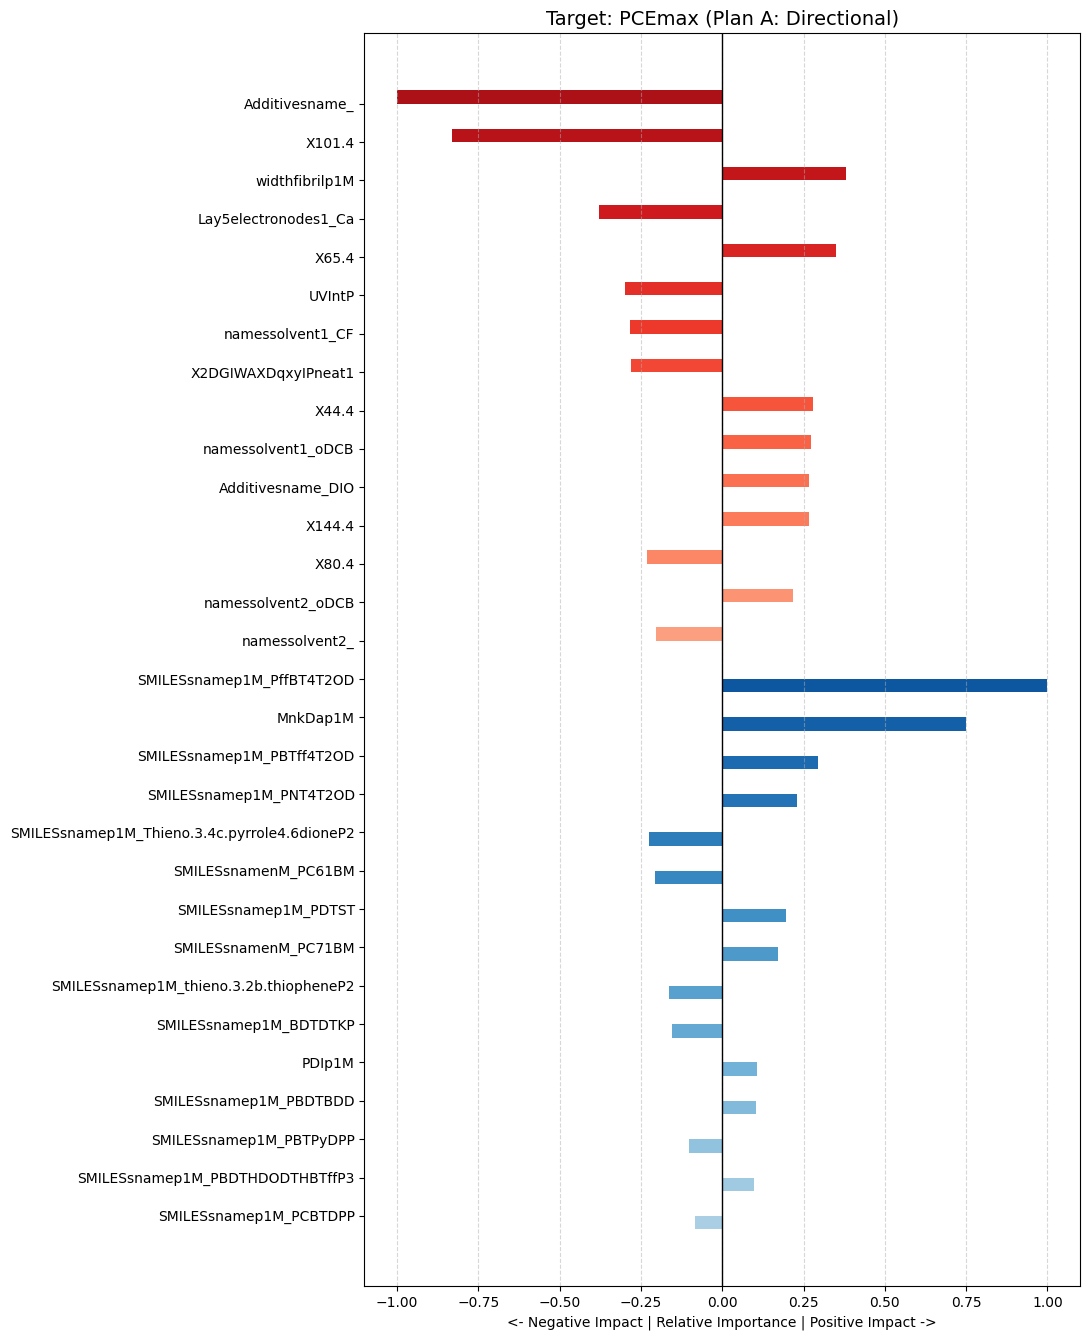

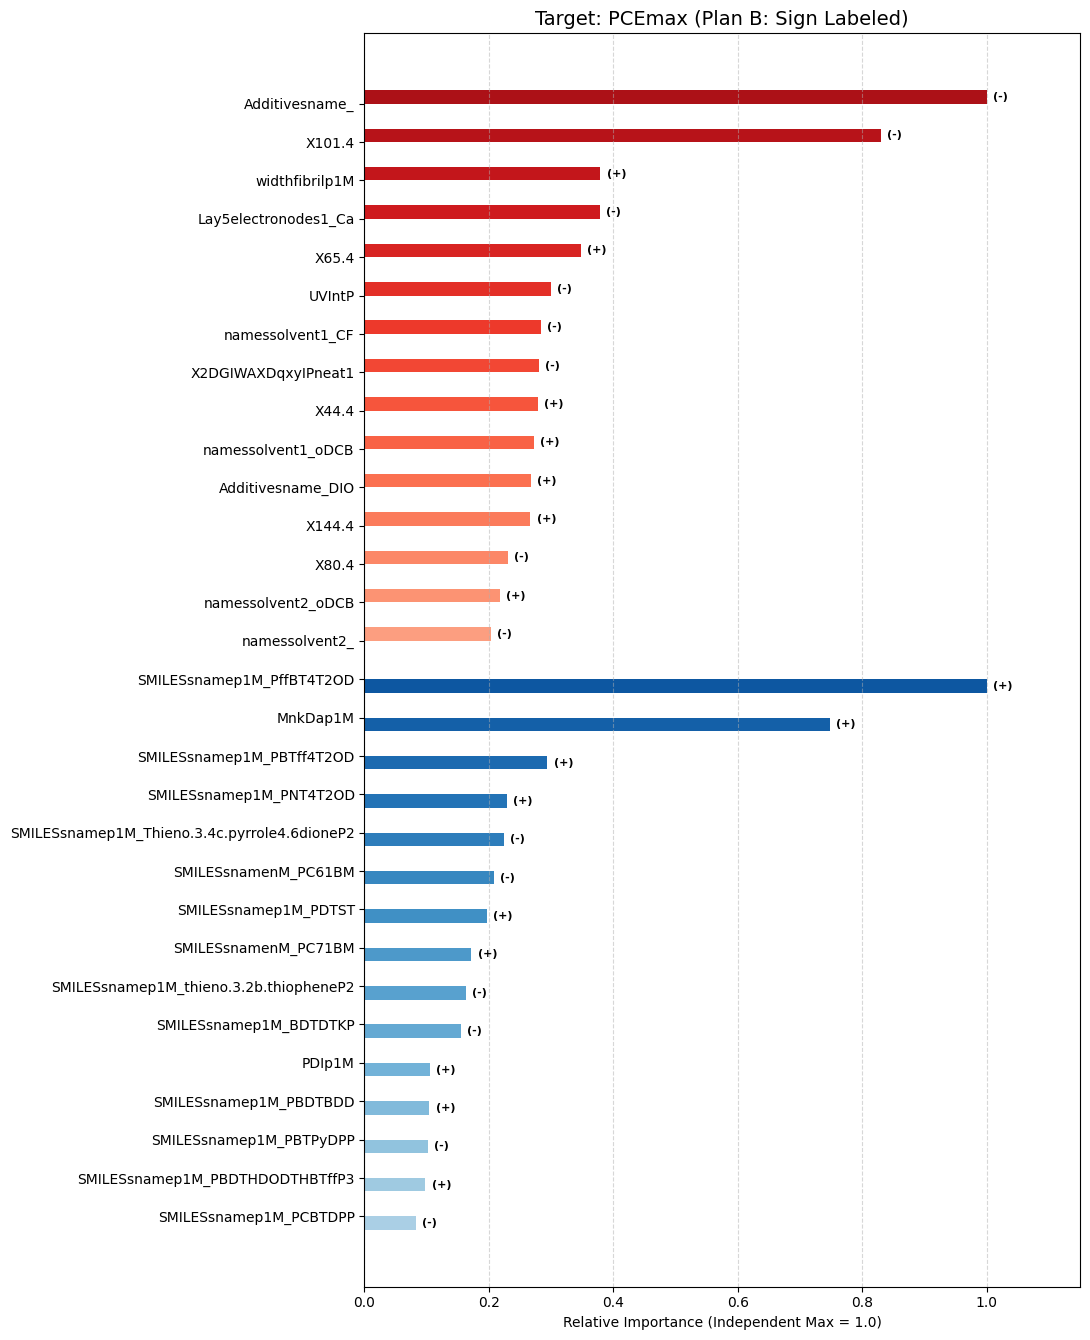

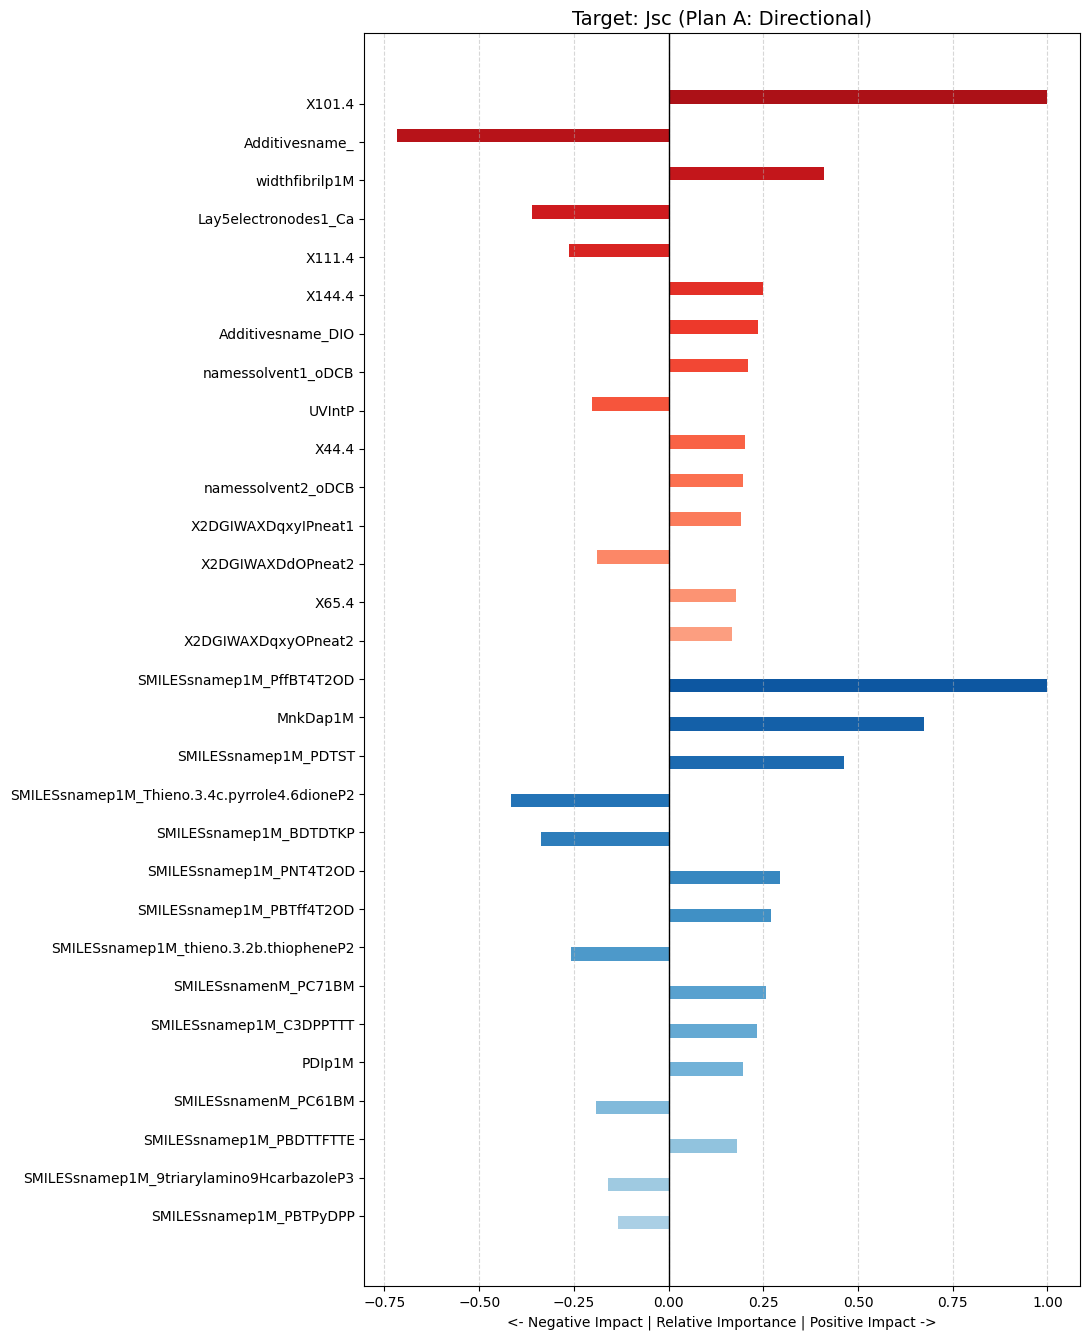

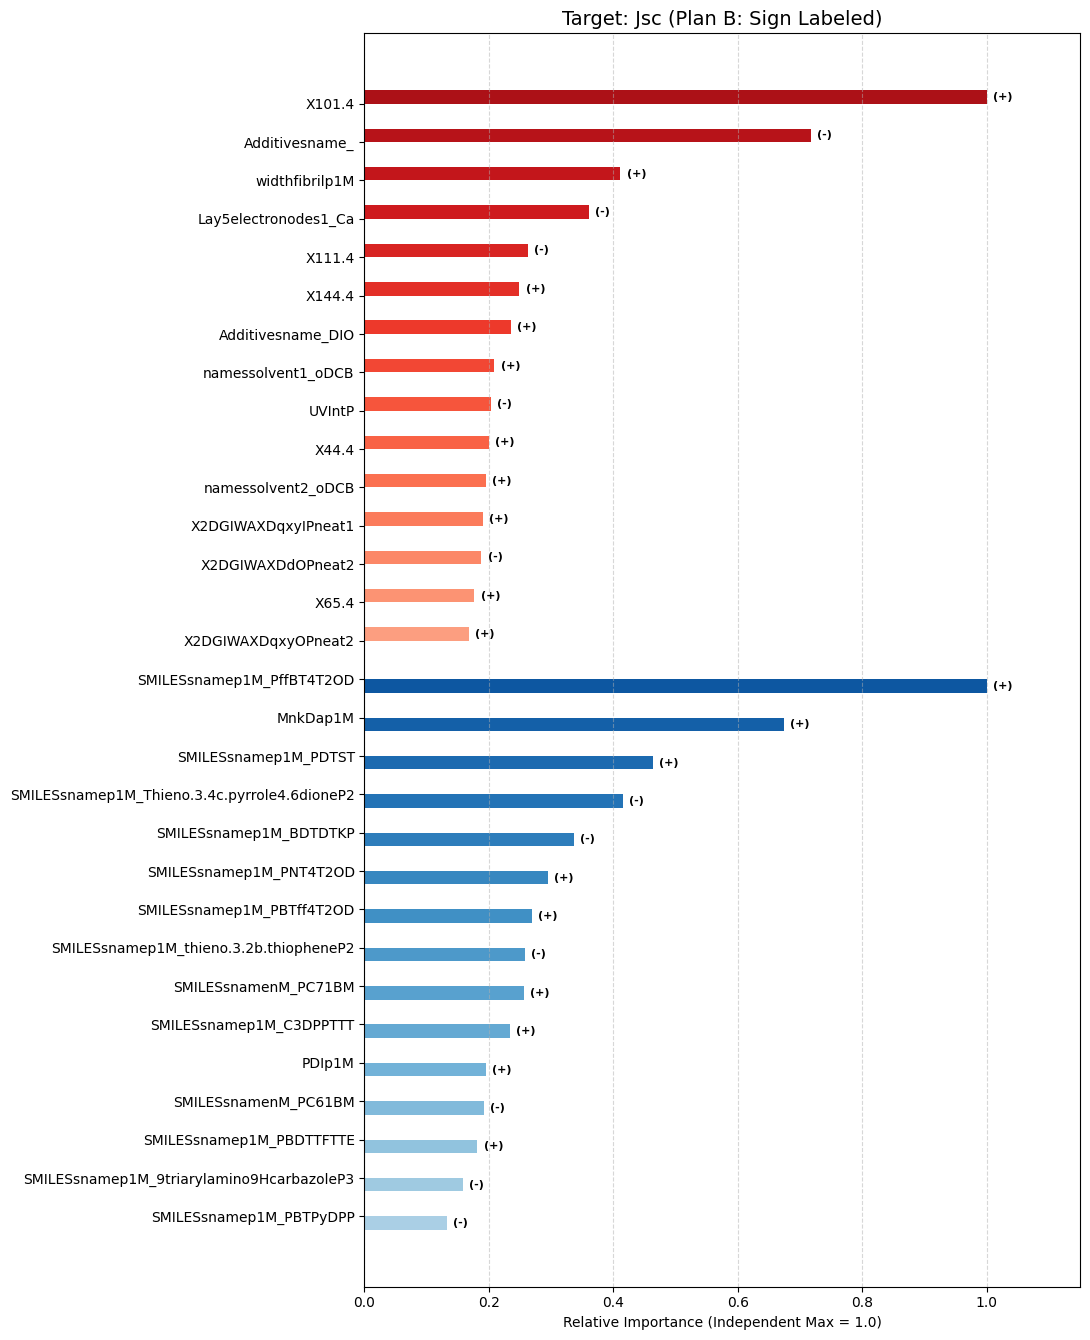

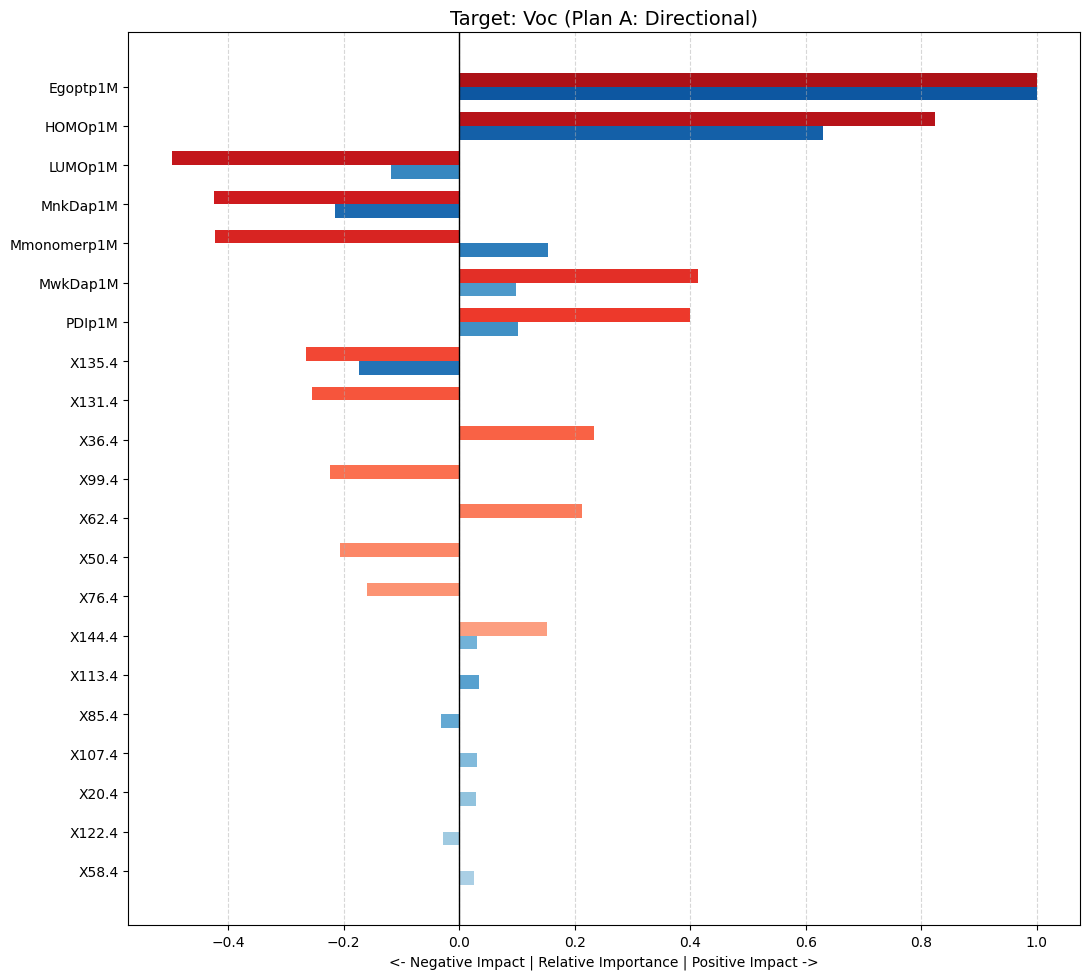

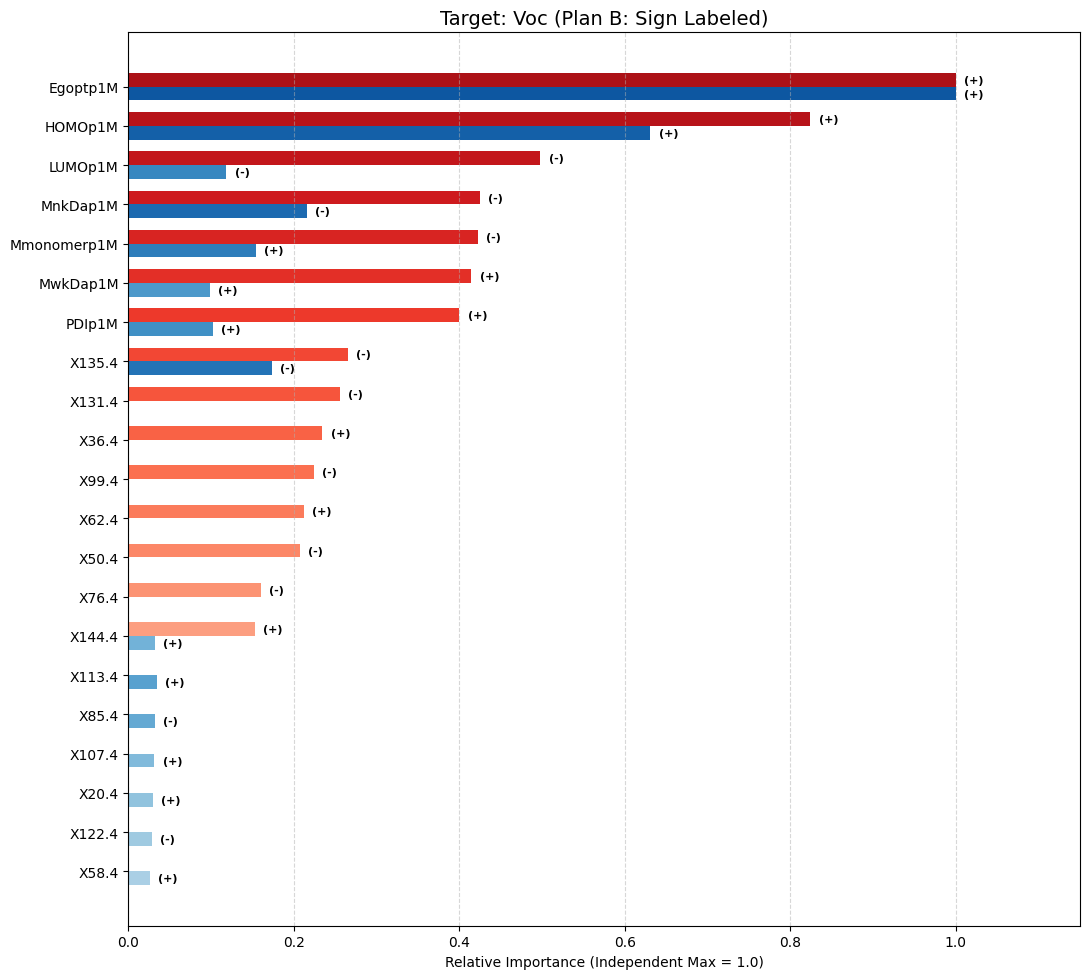

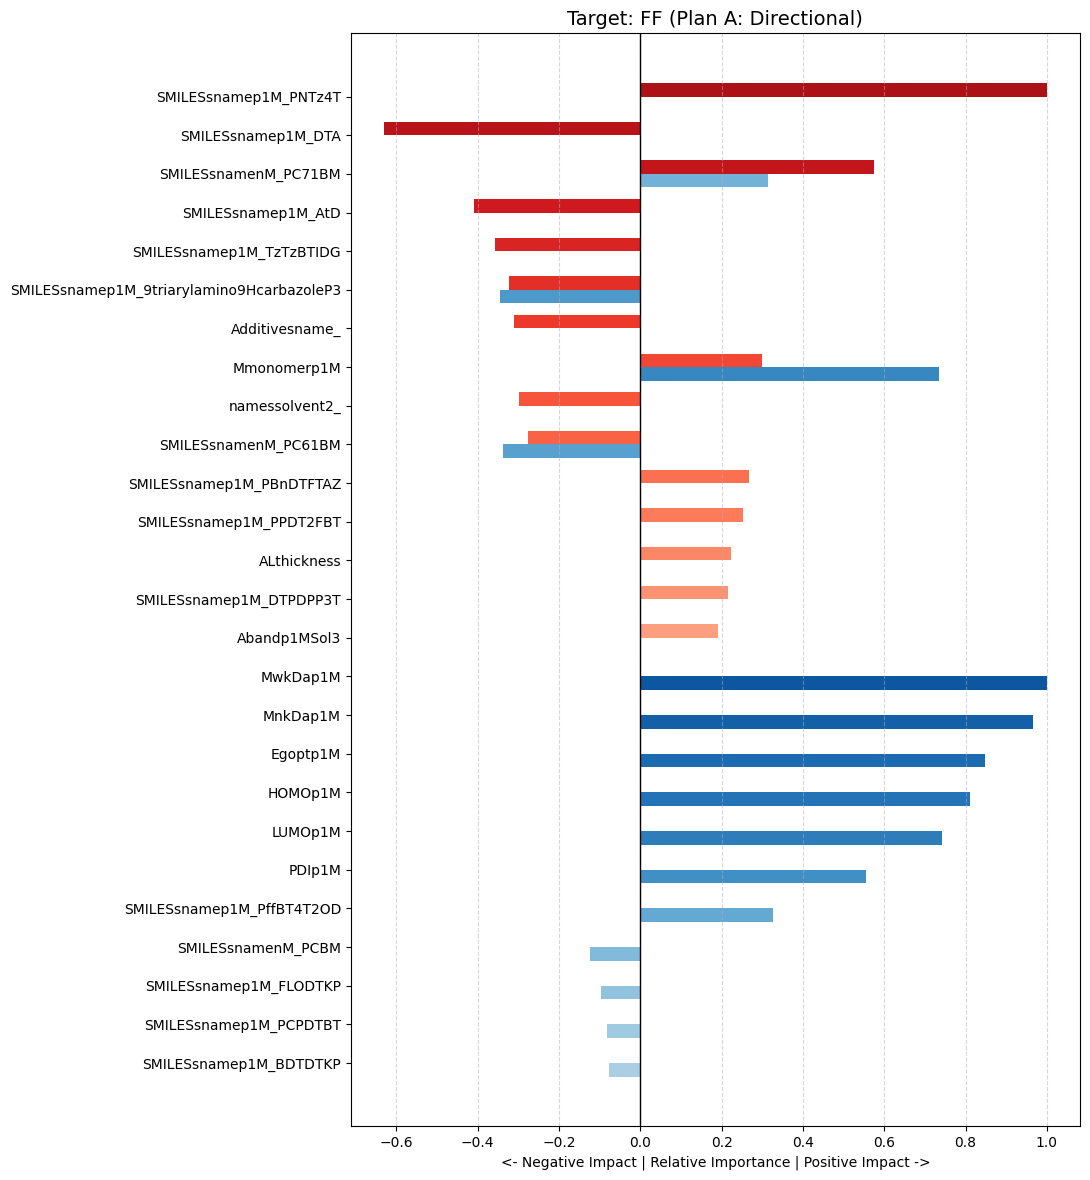

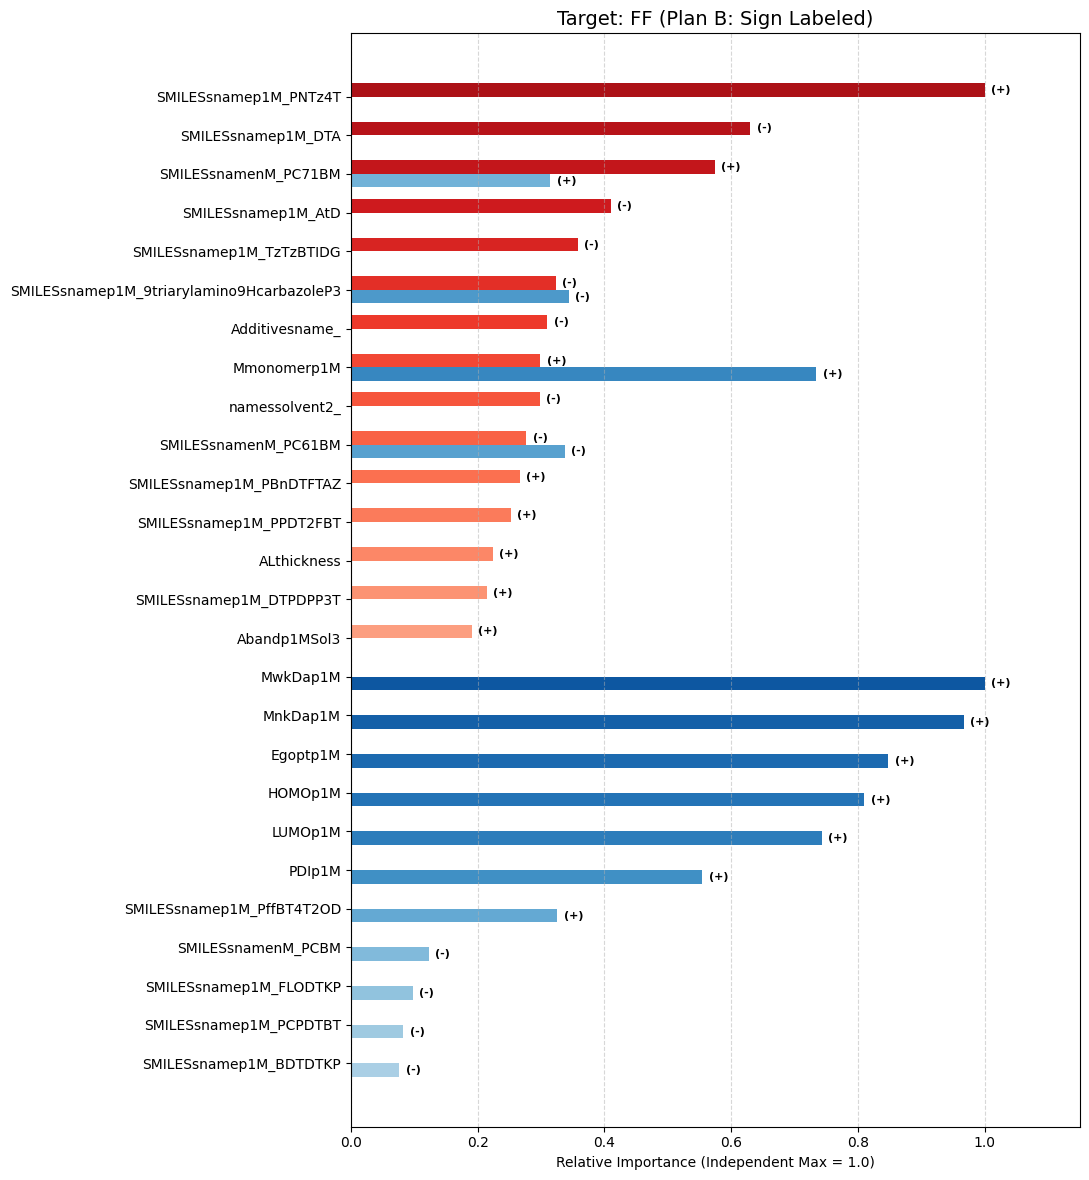


--- 全処理完了 ---
画像保存先: Feature_Importance_Impact_Analysis
ZIPファイル: Feature_Importance_Impact_Analysis_Report.zip


In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from zipfile import ZipFile

# =============================================================================
# 1. 設定：パスと対象の定義
# =============================================================================
FI_MASTER_FILE = 'Feature_Importance_All_Models_Master_20260112.csv'
RAW_DATA_PATH = "/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/20220127_PLS 202201 ALL/20251216_for_making_collect_data_nm_baseall_OHFP_csv/rebuilt_merged_data/"

OUTPUT_DIR = "Feature_Importance_Impact_Analysis"
DIR_PLAN_A = os.path.join(OUTPUT_DIR, "PlanA_Directional")
DIR_PLAN_B = os.path.join(OUTPUT_DIR, "PlanB_SignLabeled")

for d in [DIR_PLAN_A, DIR_PLAN_B]:
    os.makedirs(d, exist_ok=True)

# ターゲットと対応する生データファイルの設定
target_configs = {
    ("PCEmax", "補完"): "m_all_FP_rebuilt.csv",
    ("PCEmax", "未補完"): "n_base_OH_rebuilt.csv",
    ("Jsc", "補完"): "m_all_FP_rebuilt.csv",
    ("Jsc", "未補完"): "n_base_OH_rebuilt.csv",
    ("Voc", "補完"): "m_base_FP_rebuilt.csv",
    ("Voc", "未補完"): "n_base_FP_rebuilt.csv",
    ("FF", "補完"): "m_all_OH_rebuilt.csv",
    ("FF", "未補完"): "n_base_OH_rebuilt.csv"
}

# =============================================================================
# 2. 補助関数の定義
# =============================================================================
def get_rank_color(cmap_name, rank, total=15):
    cmap = plt.get_cmap(cmap_name)
    val = 0.85 - (rank / total) * 0.55
    return cmap(val)

def get_impact_info(df_raw, target, feature):
    """生データから正負の寄与を判定するコアロジック"""
    if df_raw is None or feature not in df_raw.columns:
        return 0, "Neutral"
    valid_data = df_raw[[feature, target]].dropna()
    if len(valid_data) < 2: return 0, "Neutral"
    
    feat_vals, tgt_vals = valid_data[feature], valid_data[target]
    # 2値判定
    if set(feat_vals.unique()).issubset({0, 1}):
        val = tgt_vals[feat_vals == 1].mean() - tgt_vals[feat_vals == 0].mean()
    else:
        val = feat_vals.corr(tgt_vals)
    
    trend = "Positive" if val > 0.0001 else ("Negative" if val < -0.0001 else "Neutral")
    return val, trend

# =============================================================================
# 3. メイン処理：可視化と保存
# =============================================================================
df = pd.read_csv(FI_MASTER_FILE)
targets = df['Target'].unique()

# 生データのキャッシュ（何度も読み込まないため）
raw_data_cache = {}

for target in targets:
    df_t = df[df['Target'] == target].copy()
    
    # --- データの準備 (Top 15抽出) ---
    def prepare_sub_df(imp_type):
        sub = df_t[df_t['Imputation_Type'] == imp_type].copy()
        if sub.empty: return sub
        v_max = sub['Importance_Mean'].max()
        sub['Norm_Imp'] = sub['Importance_Mean'] / v_max if v_max > 0 else 0
        sub = sub.sort_values('Norm_Imp', ascending=False).head(15)
        sub['Rank'] = range(len(sub))
        return sub

    df_imp = prepare_sub_df('補完')
    df_non = prepare_sub_df('未補完')

    # 表示用特徴量リスト
    ordered_features = df_imp['Feature'].tolist() if not df_imp.empty else []
    for f in (df_non['Feature'].tolist() if not df_non.empty else []):
        if f not in ordered_features: ordered_features.append(f)
    display_features = ordered_features[::-1]
    
    # 生データの読み込み
    for itype in ['補完', '未補完']:
        key = (target, itype)
        if key in target_configs:
            fpath = os.path.join(RAW_DATA_PATH, target_configs[key])
            if os.path.exists(fpath) and key not in raw_data_cache:
                raw_data_cache[key] = pd.read_csv(fpath)

    # ---------------------------------------------------------
    # 描画ループ (Plan A & Plan B)
    # ---------------------------------------------------------
    for plan in ['A', 'B']:
        fig, ax = plt.subplots(figsize=(11, len(display_features) * 0.4 + 1.5))
        height = 0.35
        y_pos = np.arange(len(display_features))
        
        for i, feature in enumerate(display_features):
            # 共通設定: 補完(imp)と未補完(non)の辞書作成
            for sub_df, itype, cmap, offset in [(df_imp, '補完', 'Reds', height/2), 
                                               (df_non, '未補完', 'Blues', -height/2)]:
                if not sub_df.empty and feature in sub_df['Feature'].values:
                    d = sub_df[sub_df['Feature'] == feature].iloc[0]
                    _, trend = get_impact_info(raw_data_cache.get((target, itype)), target, feature)
                    
                    if plan == 'A':
                        val = d['Norm_Imp'] * (-1 if trend == "Negative" else 1)
                        ax.barh(i + offset, val, height=height, color=get_rank_color(cmap, d['Rank']))
                    else: # Plan B
                        ax.barh(i + offset, d['Norm_Imp'], height=height, color=get_rank_color(cmap, d['Rank']))
                        sign = "(+)" if trend == "Positive" else ("(-)" if trend == "Negative" else "")
                        ax.text(d['Norm_Imp'] + 0.01, i + offset, sign, va='center', fontsize=8, fontweight='bold')

        ax.set_yticks(y_pos)
        ax.set_yticklabels(display_features)
        ax.grid(axis='x', linestyle='--', alpha=0.5)
        
        if plan == 'A':
            ax.axvline(0, color='black', linewidth=1)
            ax.set_title(f"Target: {target} (Plan A: Directional)", fontsize=14)
            ax.set_xlabel("<- Negative Impact | Relative Importance | Positive Impact ->")
            save_path = os.path.join(DIR_PLAN_A, f"{target}_PlanA_Directional.png")
        else:
            ax.set_xlim(0, 1.15)
            ax.set_title(f"Target: {target} (Plan B: Sign Labeled)", fontsize=14)
            ax.set_xlabel("Relative Importance (Independent Max = 1.0)")
            save_path = os.path.join(DIR_PLAN_B, f"{target}_PlanB_SignLabeled.png")

        plt.tight_layout()
        plt.savefig(save_path, dpi=300)
        plt.show() # コンソール表示
        plt.close(fig)

# =============================================================================
# 4. ZIP圧縮
# =============================================================================
zip_name = "Feature_Importance_Impact_Analysis_Report.zip"
with ZipFile(zip_name, 'w') as zipf:
    for root, dirs, files in os.walk(OUTPUT_DIR):
        for file in files:
            zipf.write(os.path.join(root, file), arcname=os.path.join(os.path.relpath(root, OUTPUT_DIR), file))

print(f"\n--- 全処理完了 ---")
print(f"画像保存先: {OUTPUT_DIR}")
print(f"ZIPファイル: {zip_name}")

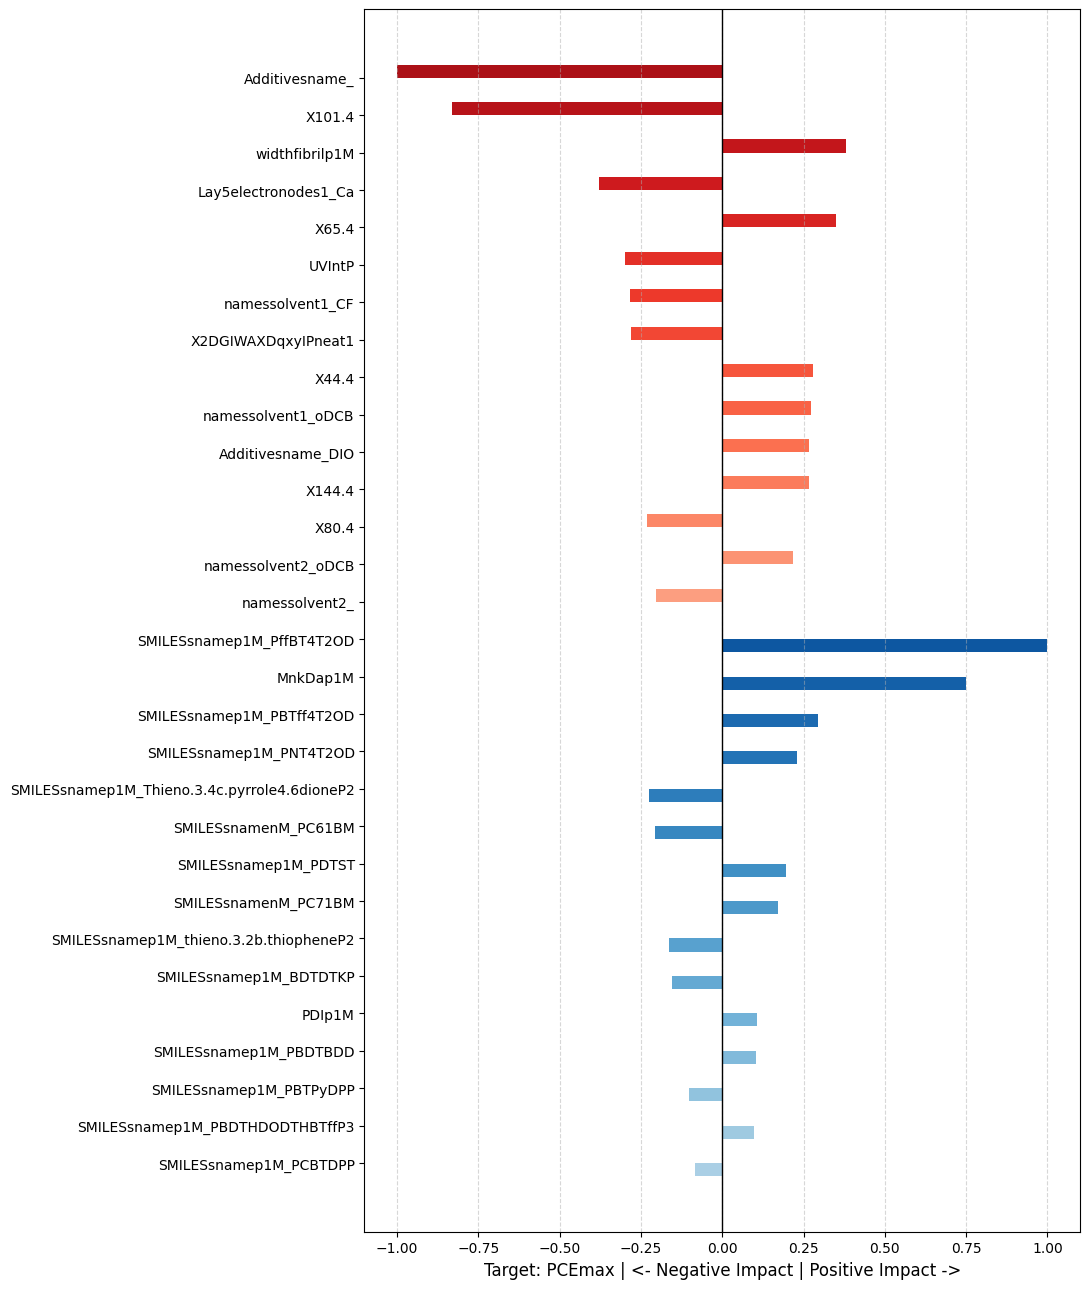

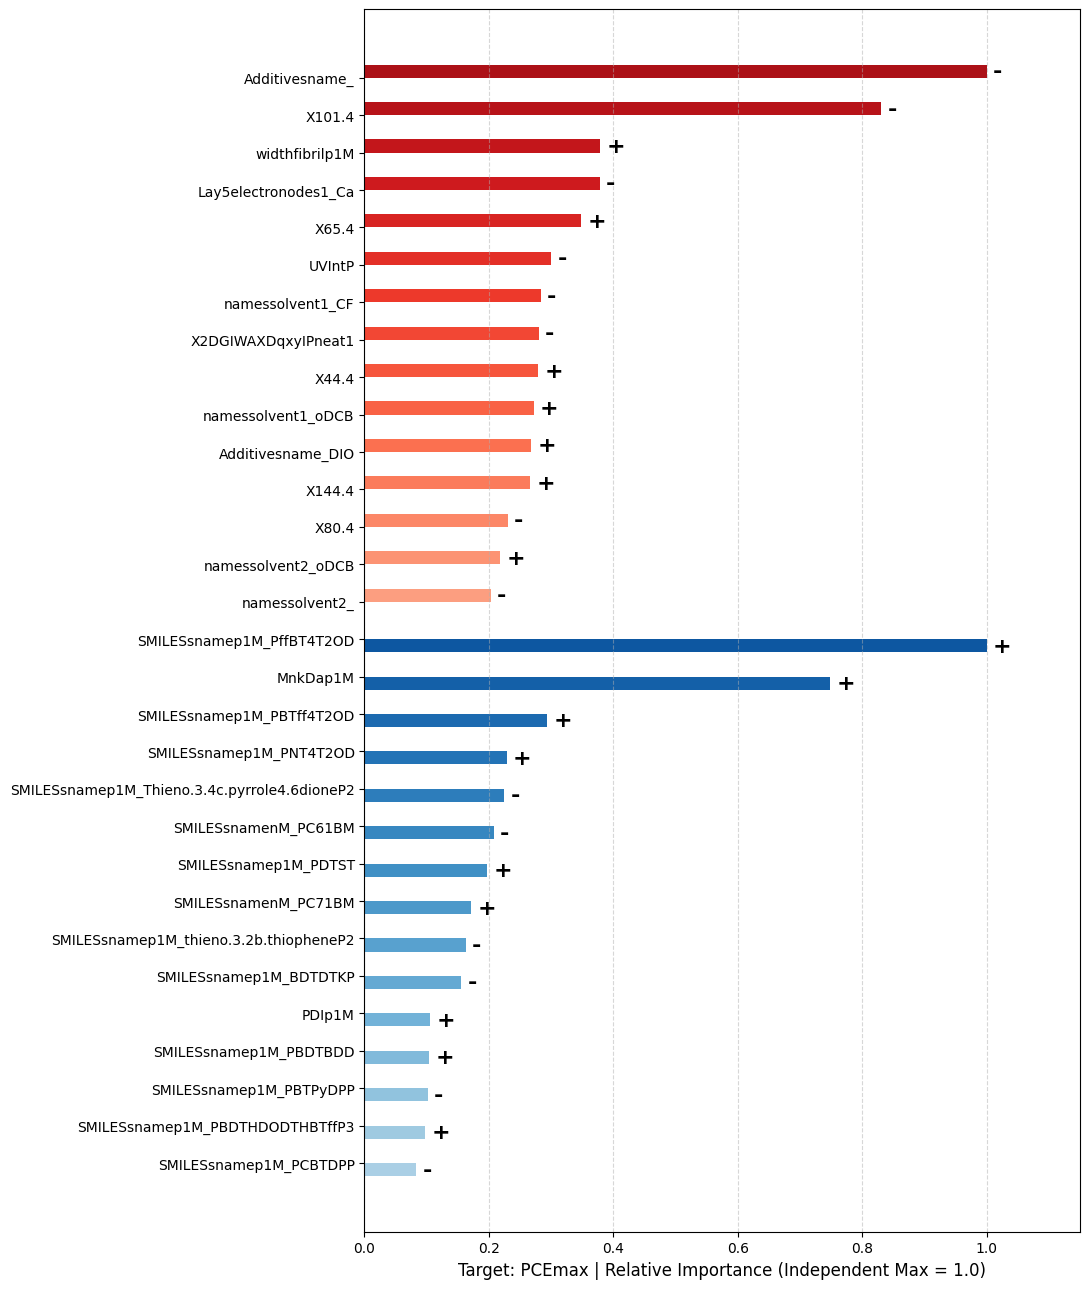

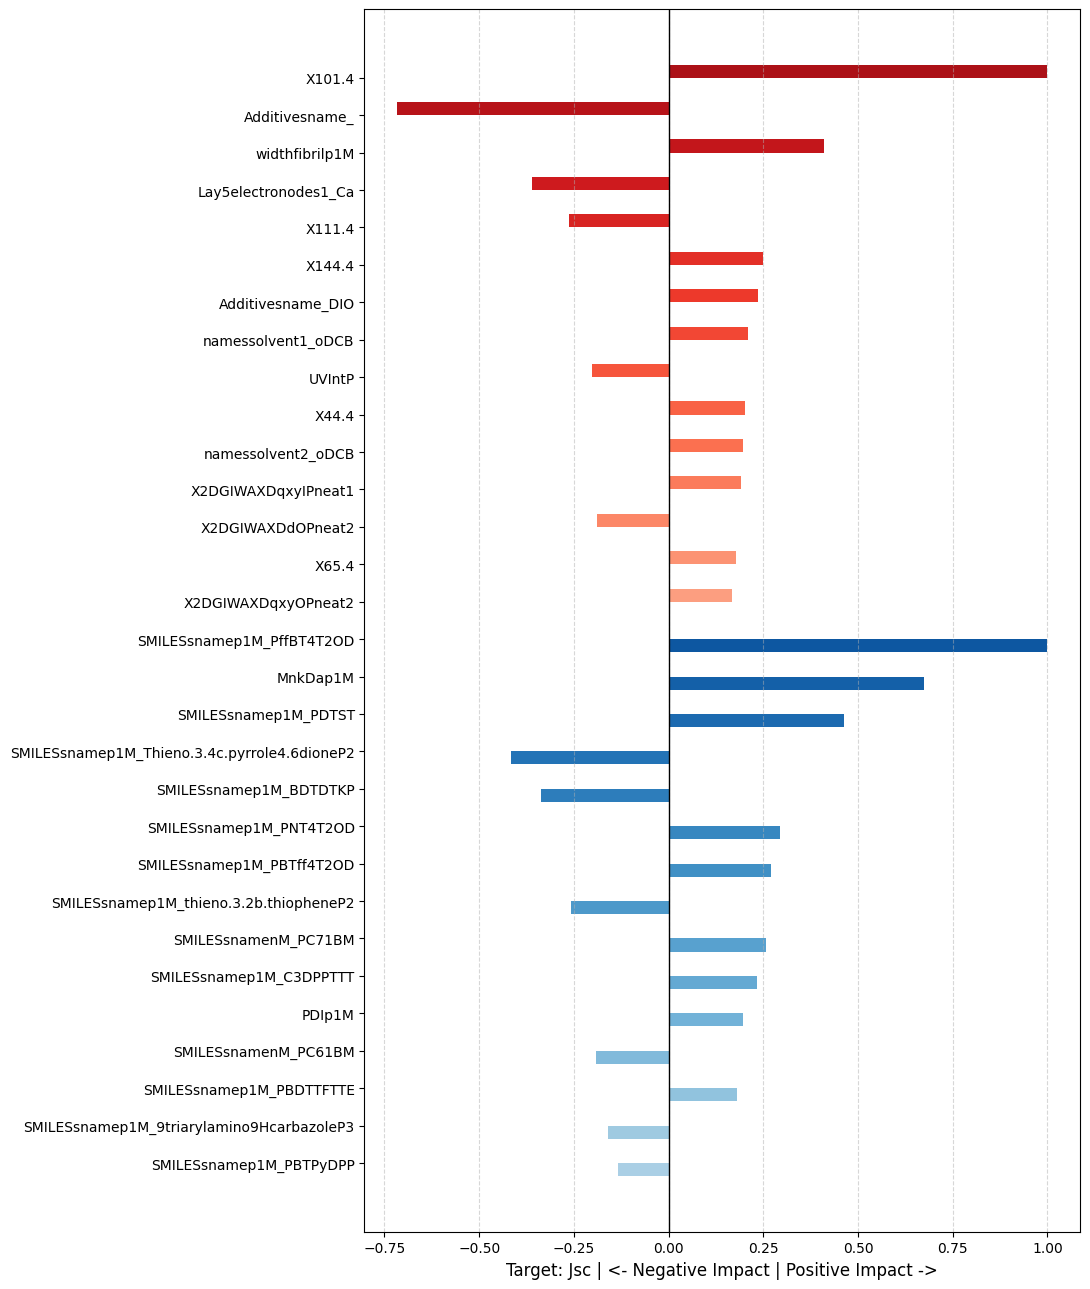

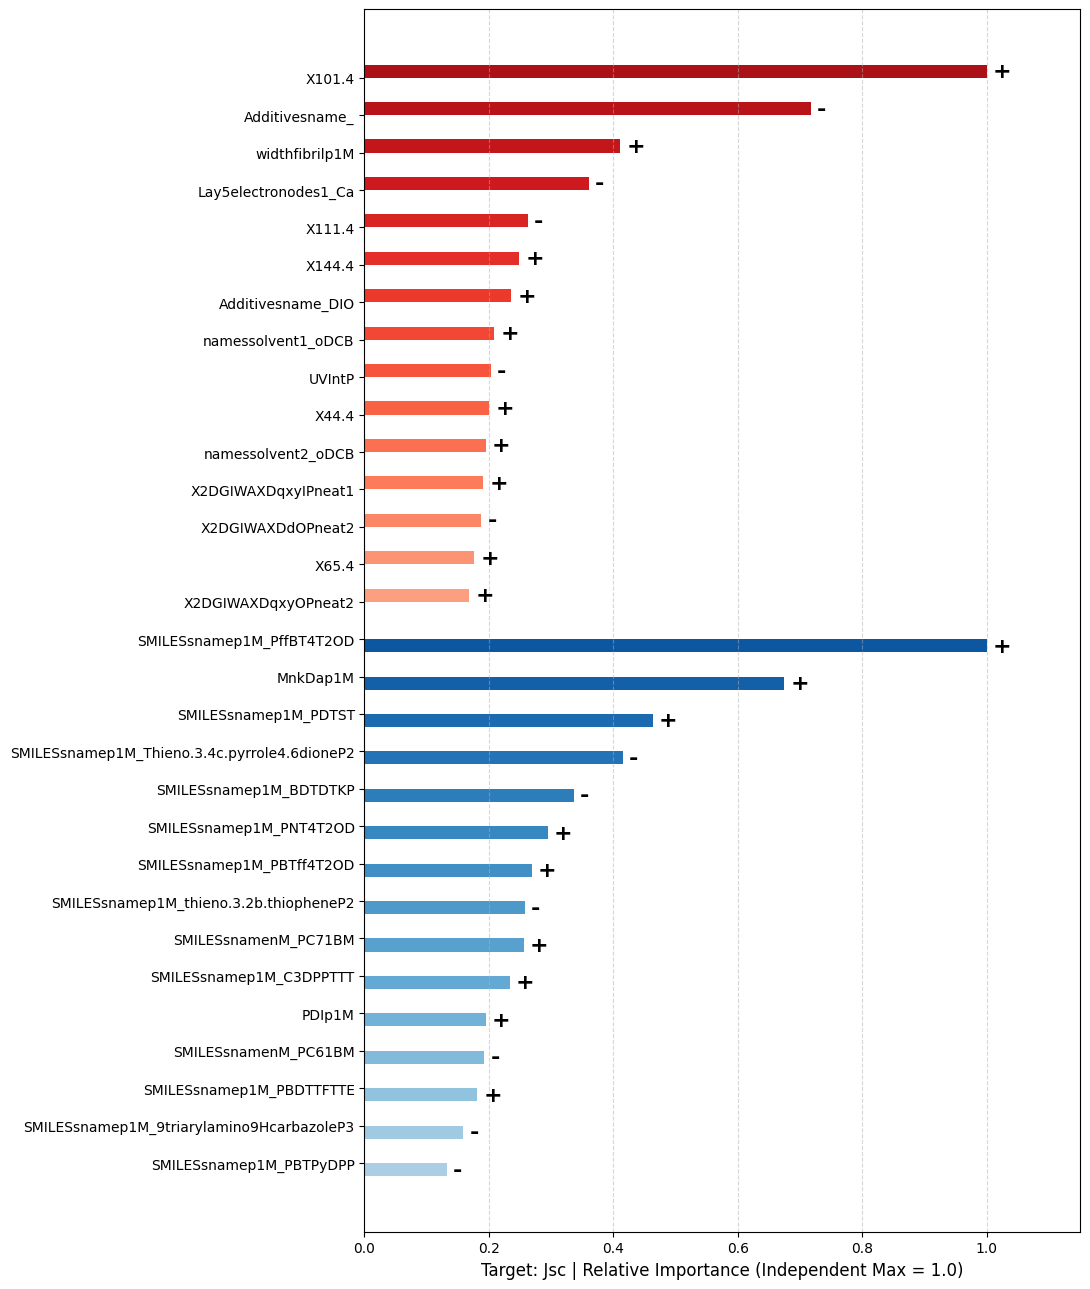

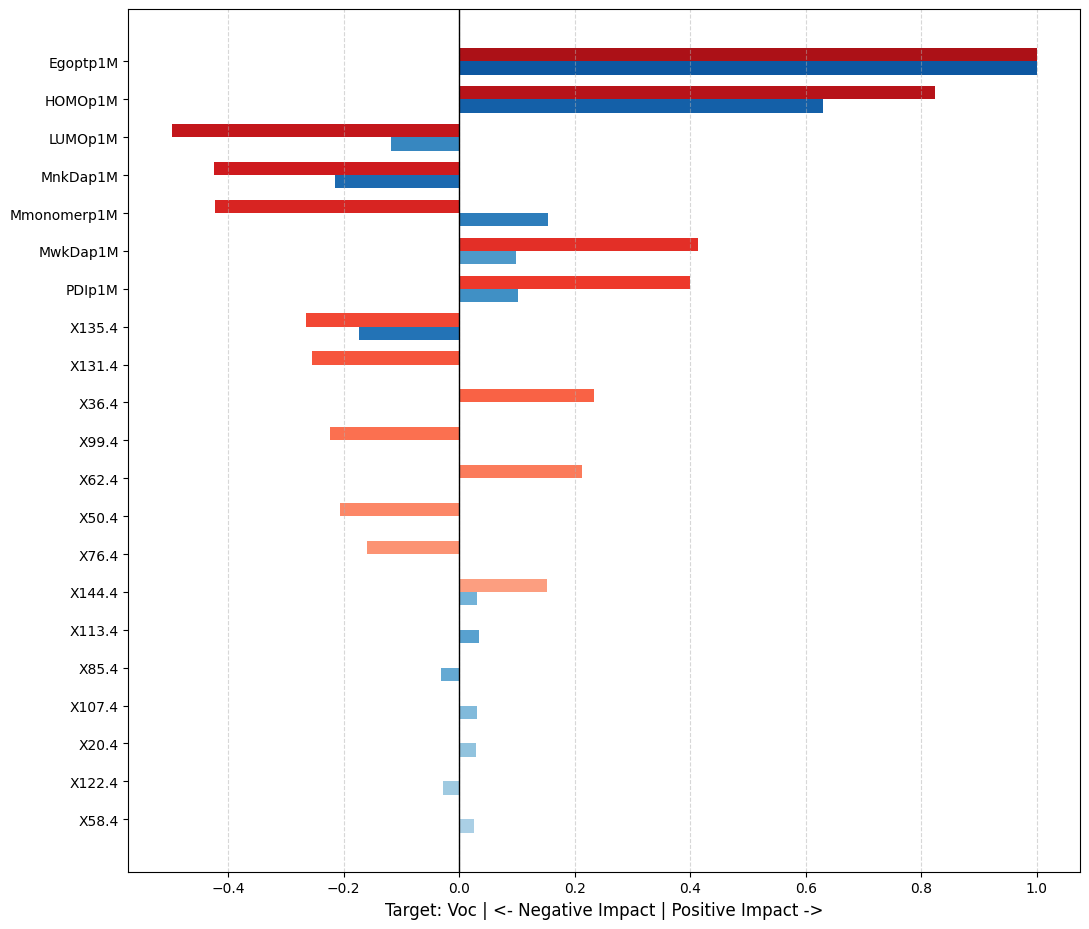

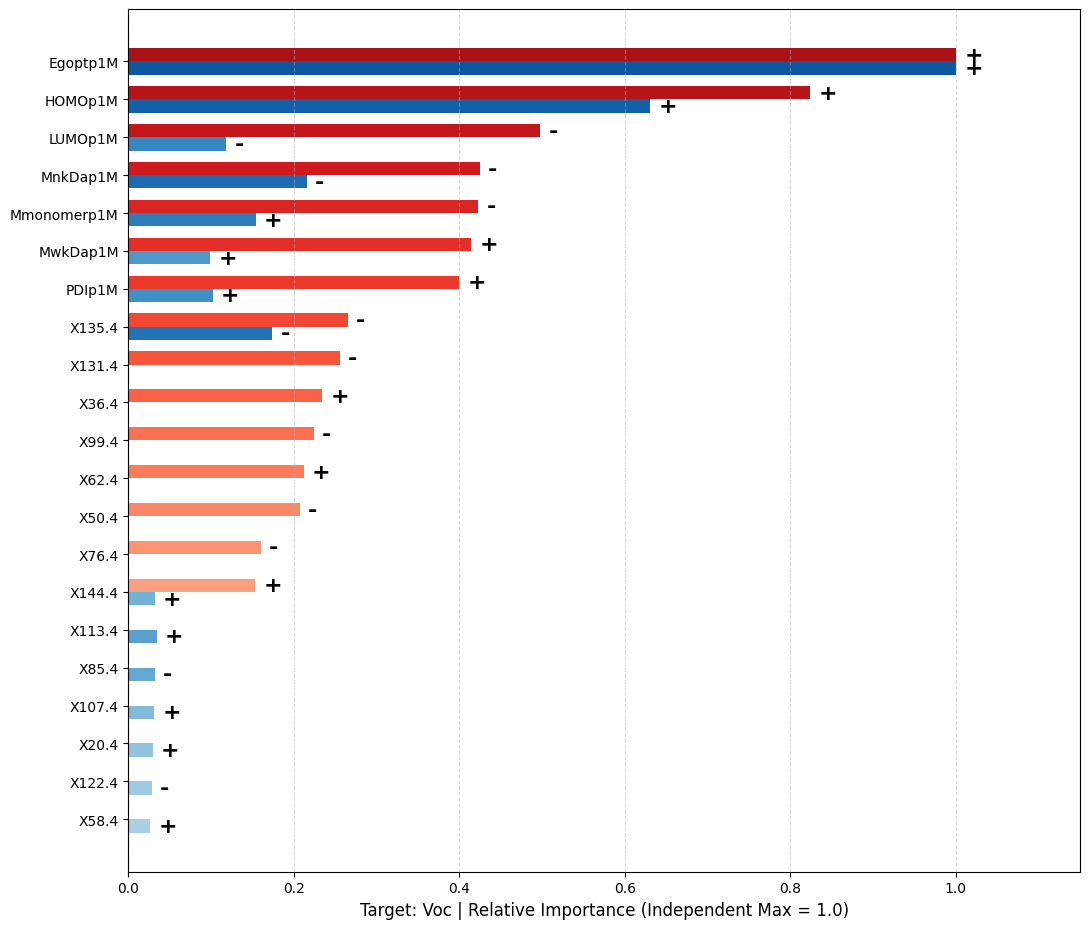

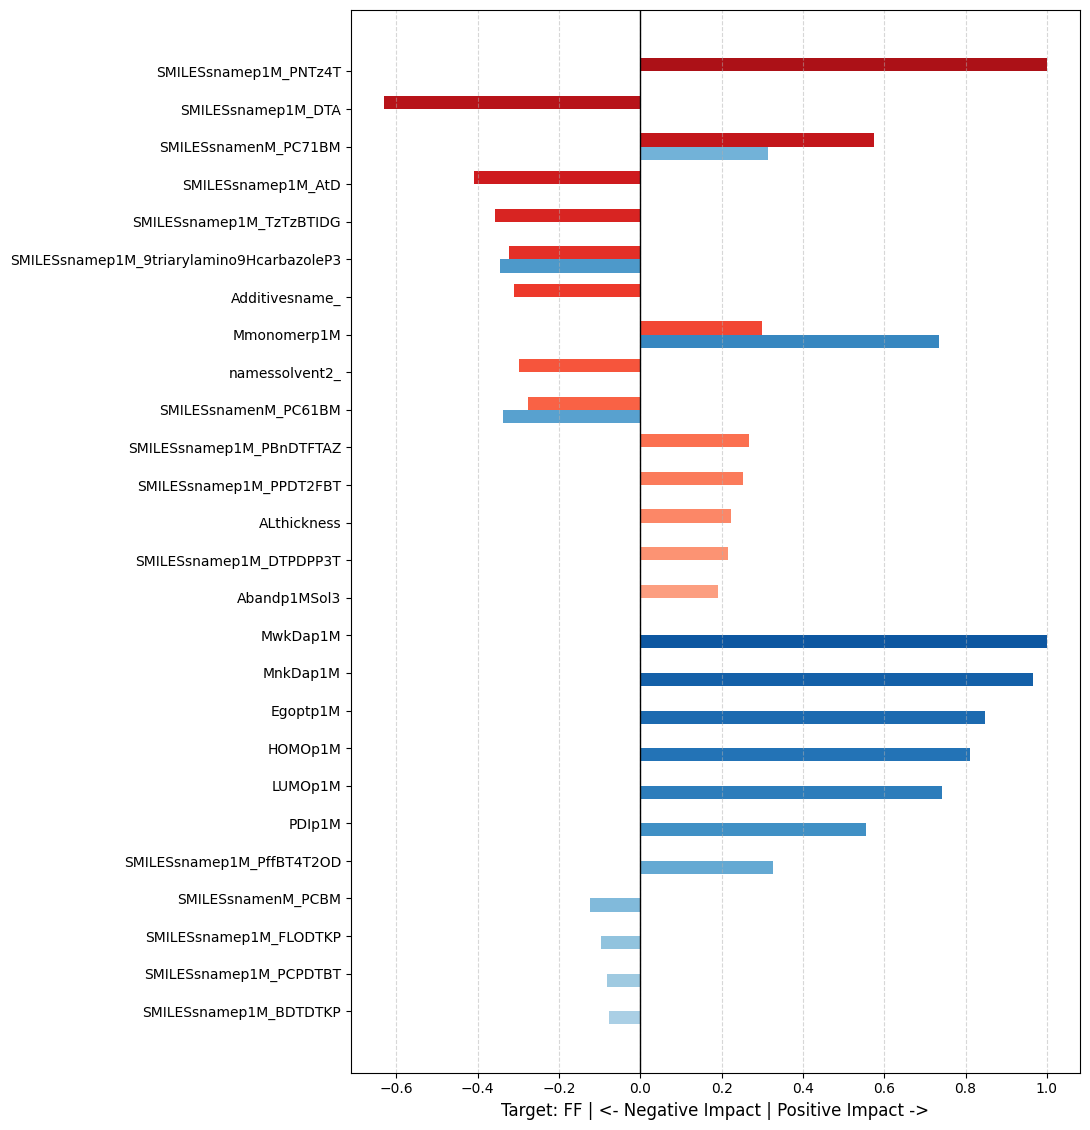

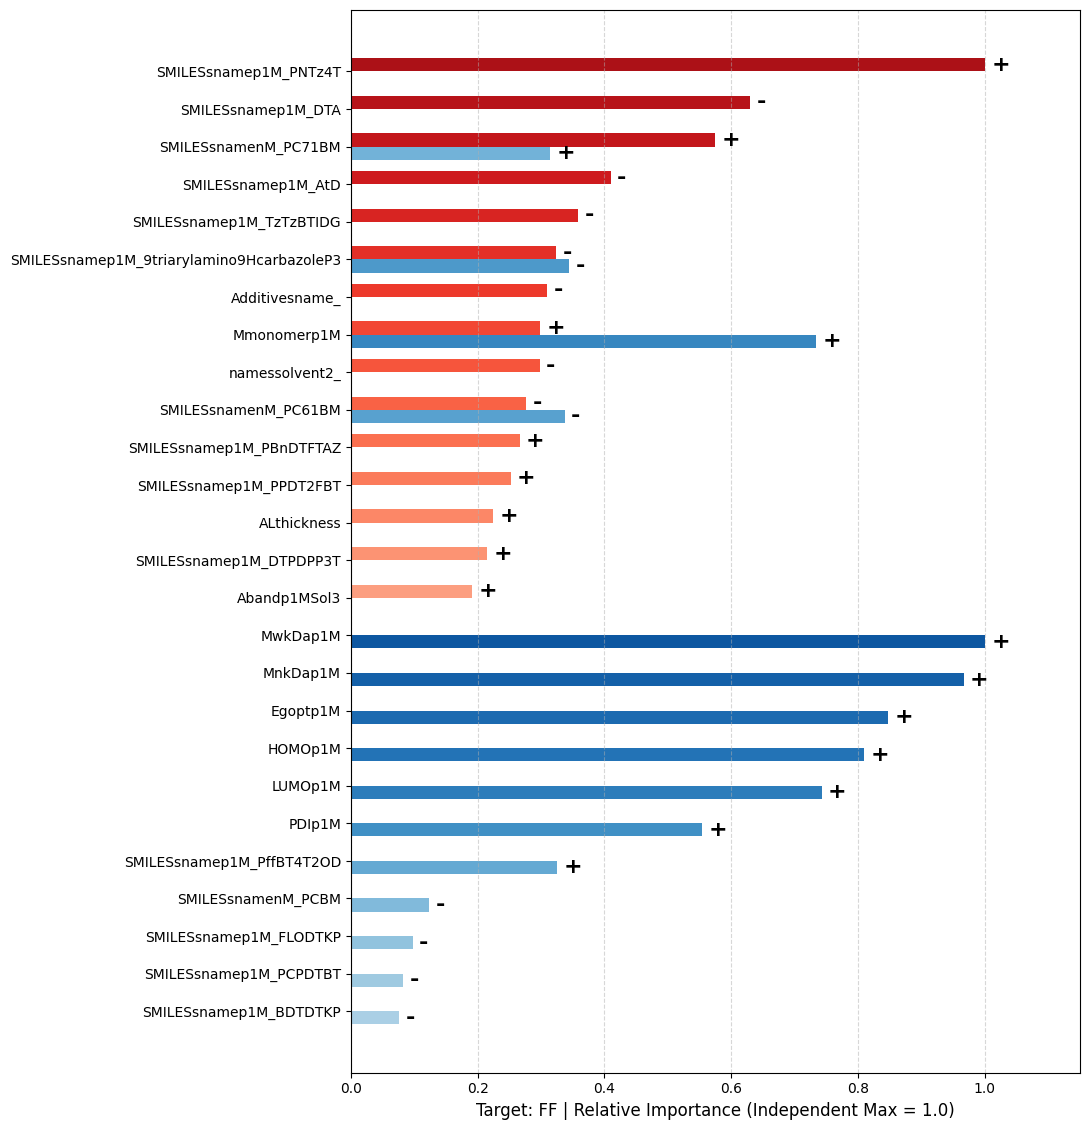


--- 処理完了 ---
ZIP: Feature_Importance_Impact_Analysis_Report.zip


In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from zipfile import ZipFile

# =============================================================================
# 1. 設定：パスと対象の定義
# =============================================================================
FI_MASTER_FILE = 'Feature_Importance_All_Models_Master_20260112.csv'
RAW_DATA_PATH = "/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/20220127_PLS 202201 ALL/20251216_for_making_collect_data_nm_baseall_OHFP_csv/rebuilt_merged_data/"

OUTPUT_DIR = "Feature_Importance_Impact_Analysis"
DIR_PLAN_A = os.path.join(OUTPUT_DIR, "PlanA_Directional")
DIR_PLAN_B = os.path.join(OUTPUT_DIR, "PlanB_SignLabeled")

for d in [DIR_PLAN_A, DIR_PLAN_B]:
    os.makedirs(d, exist_ok=True)

target_configs = {
    ("PCEmax", "補完"): "m_all_FP_rebuilt.csv",
    ("PCEmax", "未補完"): "n_base_OH_rebuilt.csv",
    ("Jsc", "補完"): "m_all_FP_rebuilt.csv",
    ("Jsc", "未補完"): "n_base_OH_rebuilt.csv",
    ("Voc", "補完"): "m_base_FP_rebuilt.csv",
    ("Voc", "未補完"): "n_base_FP_rebuilt.csv",
    ("FF", "補完"): "m_all_OH_rebuilt.csv",
    ("FF", "未補完"): "n_base_OH_rebuilt.csv"
}

# =============================================================================
# 2. 補助関数の定義
# =============================================================================
def get_rank_color(cmap_name, rank, total=15):
    cmap = plt.get_cmap(cmap_name)
    val = 0.85 - (rank / total) * 0.55
    return cmap(val)

def get_impact_info(df_raw, target, feature):
    if df_raw is None or feature not in df_raw.columns:
        return 0, "Neutral"
    valid_data = df_raw[[feature, target]].dropna()
    if len(valid_data) < 2: return 0, "Neutral"
    
    feat_vals, tgt_vals = valid_data[feature], valid_data[target]
    if set(feat_vals.unique()).issubset({0, 1}):
        val = tgt_vals[feat_vals == 1].mean() - tgt_vals[feat_vals == 0].mean()
    else:
        val = feat_vals.corr(tgt_vals)
    
    trend = "Positive" if val > 0.0001 else ("Negative" if val < -0.0001 else "Neutral")
    return val, trend

# =============================================================================
# 3. メイン処理：可視化と保存
# =============================================================================
df = pd.read_csv(FI_MASTER_FILE)
targets = df['Target'].unique()
raw_data_cache = {}

for target in targets:
    df_t = df[df['Target'] == target].copy()
    
    def prepare_sub_df(imp_type):
        sub = df_t[df_t['Imputation_Type'] == imp_type].copy()
        if sub.empty: return sub
        v_max = sub['Importance_Mean'].max()
        sub['Norm_Imp'] = sub['Importance_Mean'] / v_max if v_max > 0 else 0
        sub = sub.sort_values('Norm_Imp', ascending=False).head(15)
        sub['Rank'] = range(len(sub))
        return sub

    df_imp = prepare_sub_df('補完')
    df_non = prepare_sub_df('未補完')

    ordered_features = df_imp['Feature'].tolist() if not df_imp.empty else []
    for f in (df_non['Feature'].tolist() if not df_non.empty else []):
        if f not in ordered_features: ordered_features.append(f)
    display_features = ordered_features[::-1]
    
    for itype in ['補完', '未補完']:
        key = (target, itype)
        if key in target_configs:
            fpath = os.path.join(RAW_DATA_PATH, target_configs[key])
            if os.path.exists(fpath) and key not in raw_data_cache:
                raw_data_cache[key] = pd.read_csv(fpath)

    for plan in ['A', 'B']:
        fig, ax = plt.subplots(figsize=(11, len(display_features) * 0.4 + 1.0))
        height = 0.35
        y_pos = np.arange(len(display_features))
        
        for i, feature in enumerate(display_features):
            for sub_df, itype, cmap, offset in [(df_imp, '補完', 'Reds', height/2), 
                                               (df_non, '未補完', 'Blues', -height/2)]:
                if not sub_df.empty and feature in sub_df['Feature'].values:
                    d = sub_df[sub_df['Feature'] == feature].iloc[0]
                    _, trend = get_impact_info(raw_data_cache.get((target, itype)), target, feature)
                    
                    if plan == 'A':
                        val = d['Norm_Imp'] * (-1 if trend == "Negative" else 1)
                        ax.barh(i + offset, val, height=height, color=get_rank_color(cmap, d['Rank']))
                    else: # Plan B
                        ax.barh(i + offset, d['Norm_Imp'], height=height, color=get_rank_color(cmap, d['Rank']))
                        sign = "+" if trend == "Positive" else ("-" if trend == "Negative" else "")
                        # 符号サイズを16（約2倍）に変更
                        ax.text(d['Norm_Imp'] + 0.01, i + offset, sign, va='center', fontsize=16, fontweight='bold')

        ax.set_yticks(y_pos)
        ax.set_yticklabels(display_features)
        ax.grid(axis='x', linestyle='--', alpha=0.5)
        
        # タイトル(set_title)を削除しました
        if plan == 'A':
            ax.axvline(0, color='black', linewidth=1)
            ax.set_xlabel(f"Target: {target} | <- Negative Impact | Positive Impact ->", fontsize=12)
            save_path = os.path.join(DIR_PLAN_A, f"{target}_PlanA_Directional.png")
        else:
            ax.set_xlim(0, 1.15)
            ax.set_xlabel(f"Target: {target} | Relative Importance (Independent Max = 1.0)", fontsize=12)
            save_path = os.path.join(DIR_PLAN_B, f"{target}_PlanB_SignLabeled.png")

        plt.tight_layout()
        plt.savefig(save_path, dpi=300)
        plt.show() 
        plt.close(fig)

# =============================================================================
# 4. ZIP圧縮
# =============================================================================
zip_name = "Feature_Importance_Impact_Analysis_Report.zip"
with ZipFile(zip_name, 'w') as zipf:
    for root, dirs, files in os.walk(OUTPUT_DIR):
        for file in files:
            zipf.write(os.path.join(root, file), arcname=os.path.join(os.path.relpath(root, OUTPUT_DIR), file))

print(f"\n--- 処理完了 ---")
print(f"ZIP: {zip_name}")